<a href="https://colab.research.google.com/github/AlvaTF/TP-AA1-Ruiz-Toledo-Mendoza/blob/regularizacion/TP_1/TP_regresion_AA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Trabajo Práctico N° 1
####  Predicción de precios de casas

**Características de entrada en orden:**
1) CRIM: tasa de criminalidad per cápita por ciudad
2) ZN: proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies
cuadrados
3) INDUS: proporción de acres de negocios no minoristas por ciudad
4) CHAS: variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario)
5) NOX: concentración de óxidos de nitrógeno (partes por 10 millones) [parts/10M]
6) RM: número promedio de habitaciones por vivienda
7) AGE: proporción de unidades ocupadas por sus propietarios construidas antes de 1940
8) DIS: distancias ponderadas a cinco centros de empleo de Boston
9) RAD: índice de accesibilidad a las autopistas radiales
10) TAX: tasa de impuesto sobre la propiedad a valor completo por $10,000 [$/10k]
11) PTRATIO: proporción alumno-maestro por ciudad
12) B: El resultado de la ecuación B=1000(Bk - 0.63)^2 donde Bk es la proporción de negros
por ciudad
13) LSTAT: % de población de menor estatus socioeconómico

**Variable de salida (target):**

14) MEDV: Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares

**Qué representa cada registro (fila):**

Cada fila es un tramo censal del área metropolitana de Boston: un barrio o sector de unas pocas miles de personas.

#### Librerías iniciales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Estructura del dataset original

In [2]:
data_orig = pd.read_csv("house-prices-tp.csv")
print(f" Dataset de {data_orig.shape[0]:,} Registros con {data_orig.shape[1]} características")

 Dataset de 556 Registros con 14 características


In [3]:
print(f"\nPrimeras filas:")
data_orig.head()


Primeras filas:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [4]:
print(f"\nTipos de datos:")
data_orig.dtypes


Tipos de datos:


CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

#### Valores nulos o duplicados

In [5]:
print(f"Valores nulos:")
print(data_orig.isnull().sum().sort_values(ascending=False)) # Nulos por variable, en forma desc.

print(f"\nPorcentaje de nulos por columna:")
print((data_orig.isna().mean()*100).round(2).sort_values(ascending=False)) # En porcentajes

print(f"\nCantidad de registros totalmente nulos:")
print(len(data_orig[data_orig.isna().all(axis=1)])) # Fila a eliminar

print("\nFilas sin MEDV:", data_orig['MEDV'].isnull().sum()) # Fila a eliminar

Valores nulos:
PTRATIO    28
RAD        28
NOX        24
AGE        24
CHAS       23
CRIM       23
LSTAT      22
B          22
ZN         22
RM         21
MEDV       21
TAX        18
INDUS      15
DIS        15
dtype: int64

Porcentaje de nulos por columna:
PTRATIO    5.04
RAD        5.04
NOX        4.32
AGE        4.32
CHAS       4.14
CRIM       4.14
LSTAT      3.96
B          3.96
ZN         3.96
RM         3.78
MEDV       3.78
TAX        3.24
INDUS      2.70
DIS        2.70
dtype: float64

Cantidad de registros totalmente nulos:
1

Filas sin MEDV: 21


In [6]:
# Cantidad de filas completamente duplicadas
print(f"Filas con valores duplicados: {data_orig.duplicated().sum()}")

Filas con valores duplicados: 0


#### Eliminacion de filas nulas o sin MEDV

Se descartan las filas sin target (MEDV) porque no se puede evaluar ni entrenar supervisado sin etiqueta, asi como los llenos de nulos, por no aportar nada. Posteriormente, se revisa el estado del dataset post eliminación.

In [7]:
data_orig = data_orig.dropna(subset=['MEDV'])
data_orig = data_orig.dropna(how='all')
print(f"Dataset después de eliminar nulos: {data_orig.shape[0]:,} Registros con {data_orig.shape[1]} características")

print(f"\nValores nulos después de la limpieza:")
print(data_orig.isnull().sum().sort_values(ascending=False))

print(f"\nPorcentaje de nulos por columna:")
print((data_orig.isna().mean()*100).round(2).sort_values(ascending=False))

Dataset después de eliminar nulos: 535 Registros con 14 características

Valores nulos después de la limpieza:
RAD        12
CRIM       11
AGE        11
ZN         11
CHAS        9
NOX         9
LSTAT       9
B           9
TAX         9
PTRATIO     9
RM          7
DIS         5
INDUS       4
MEDV        0
dtype: int64

Porcentaje de nulos por columna:
RAD        2.24
CRIM       2.06
AGE        2.06
ZN         2.06
CHAS       1.68
NOX        1.68
LSTAT      1.68
B          1.68
TAX        1.68
PTRATIO    1.68
RM         1.31
DIS        0.93
INDUS      0.75
MEDV       0.00
dtype: float64


#### Descripciones generales

In [8]:
round(data_orig.describe(), 2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,524.00,524.00,531.00,526.00,526.00,528.00,524.00,530.00,523.00,526.00,526.00,526.00,526.00,535.00
mean,4.99,12.50,11.23,0.09,0.56,6.28,67.66,3.89,9.62,409.19,18.42,350.87,12.97,22.75
std,11.94,24.29,6.92,0.28,0.12,0.75,28.57,2.21,8.67,167.88,2.20,96.82,7.51,9.49
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.13,0.00,0.45,5.88,42.28,2.11,4.00,279.00,17.00,371.62,7.12,16.75
50%,0.29,0.00,9.69,0.00,0.54,6.20,76.50,3.32,5.00,334.00,19.00,390.94,11.46,21.20
75%,4.55,20.00,18.10,0.00,0.63,6.63,93.90,5.29,24.00,666.00,20.20,396.04,17.16,26.30
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


**Observaciones:**

**Variables con alta dispersión:**
- **CRIM** presenta un desvío estándar (11.94) más de dos veces mayor que su media (4.99), y una media muy superior a la mediana (0.29). La distribución es fuertemente asimétrica a derecha.
- **ZN** también tiene un desvío (24.29) mayor que su media (12.50); se debe revisar con más detalle su distribución.

**Variables con baja dispersión:**
- **RM** y **PTRATIO** tienen desvíos pequeños en relación a su media (alrededor del 12%), por lo que sus valores están concentrados.

**Otras variables con posibles outliers:**
- **B:** asimétrica a izquierda. El 75% de los valores supera 371, pero hay zonas con valores muy bajos (mínimo 0.32), por debajo del límite inferior de 335.
- **LSTAT** (máx. 37.97) y **DIS** (máx. 12.13) superan levemente sus límites superiores (32.2 y 10.1).
- **MEDV:** valores por encima de 40.6 son atípicos según el IQR, y el máximo de 50 corresponde a un valor de censura conocido de este dataset (precios mayores se registraron como 50).

**Variables sin outliers según el IQR pero con distribución particular:**
- **RAD** y **TAX:** el percentil 75 coincide o casi coincide con el máximo (24 y 666 vs. 711), lo que sugiere un grupo de zonas con valores muy altos separado del resto (distribución bimodal), más que outliers aislados.
- **CHAS:** binaria, con solo un 9% de zonas lindantes al río; su desvío no tiene la misma interpretación que las demás variables.

#### Visualizaciones

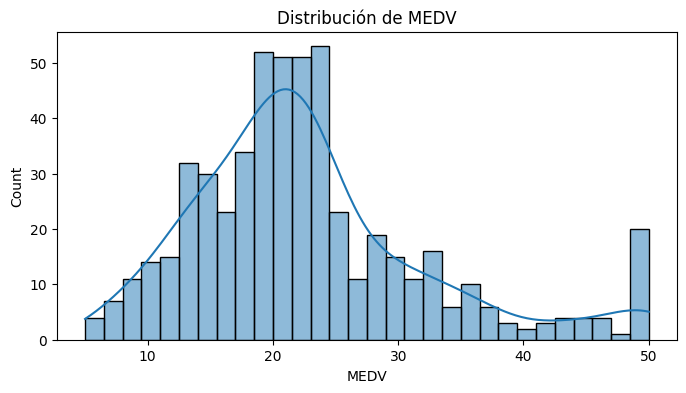

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(data_orig['MEDV'], kde=True, bins=30)
plt.title('Distribución de MEDV')
plt.show()

Los datos naturalmente presentan una distribucion practicamente normal. El problema es que parece haber un truncamiento en 50. Como se vio en la tabla anterior, este es el máximo valor presentado en el dataset. Se podría suponer que a las casas que valian más de 50 (y permitian que la distribucion sea simetrica) se les asigno un límite de 50 por defecto.

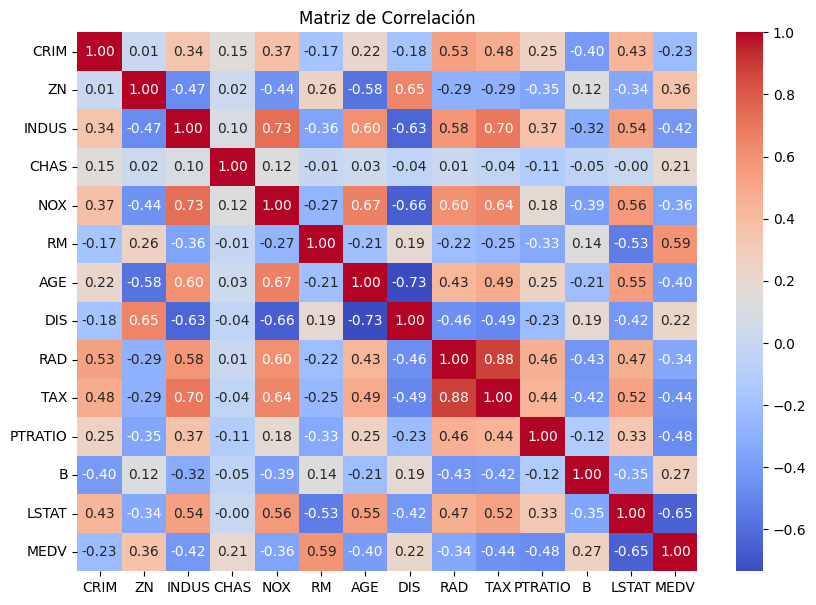

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(data_orig.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

Multicolinealidad entre predictores, mayor a 0.70:
- Alta correlacion entre RAD y TAX (r=0.88)
- Entre NOX e INDUS (r=0.73)
- Entre TAX e INDUS (r=0.70).

Relacion alta con MEDV (target):
- RM tiene una alta relacion positiva (r=0.59) y LSTAT una alta relacion negativa (r=-0.65).

Se procede a verificar estas relaciones con **scatterploxs**:

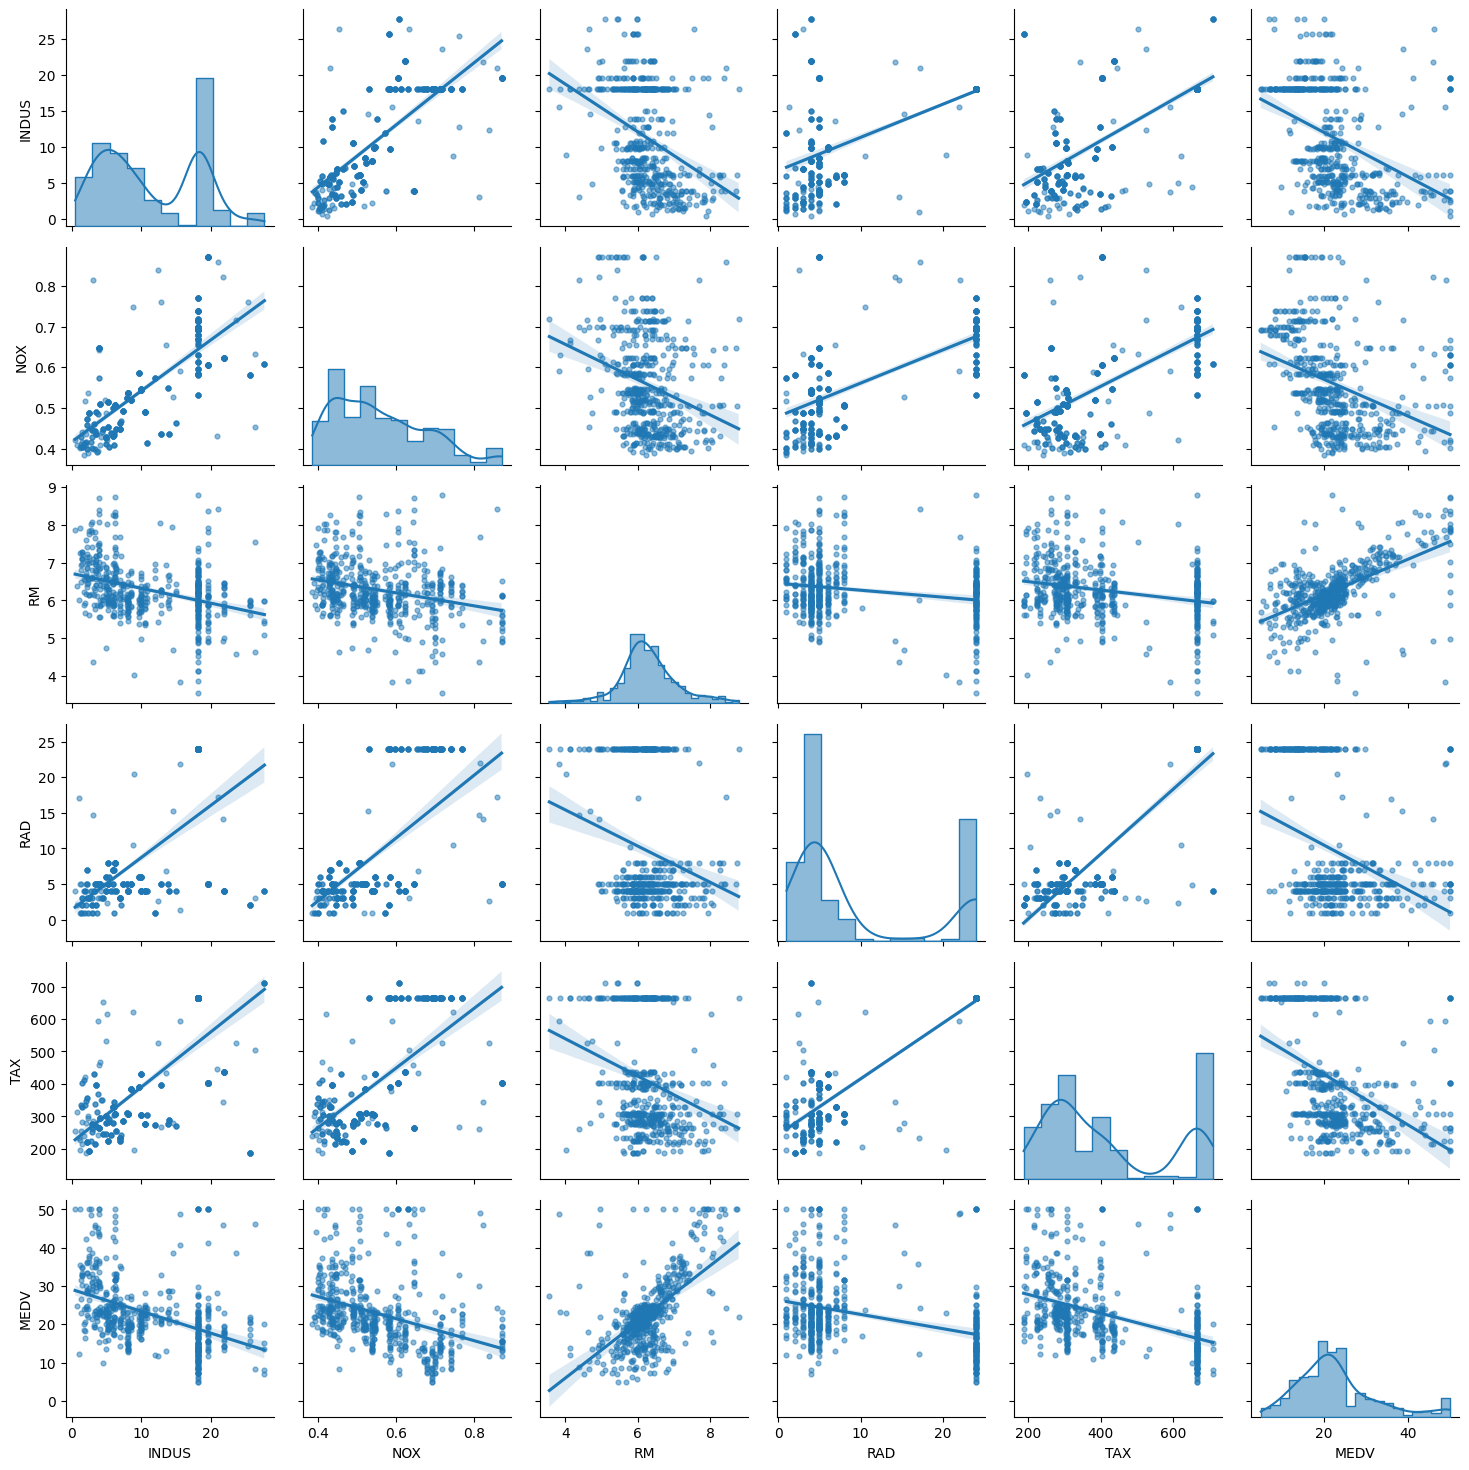

In [11]:
g = sns.PairGrid(data_orig[['INDUS', 'NOX', 'RM', 'RAD', 'TAX', 'MEDV']])
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot, scatter_kws={'alpha': 0.5, 's': 12})

Detalles:
- Correlación entre RAD y TAX: hay dos grupos separados ya que hay una nube entre RAD 1-8 y otra columna en RAD=24, con un vacío total entre 8 y 24. La más fuerte es la primera.
- Entre NOX e INDUS: similar al anterior pero sin separaciones tan marcadas entre grupos.
- Entre TAX e INDUS: la nube sube de forma bastante continua en todo el rango, aunque también hay una concentración vertical en INDUS alrededor de 18 (más suelo industrial, más óxidos de nitrógeno)

#### Outliers

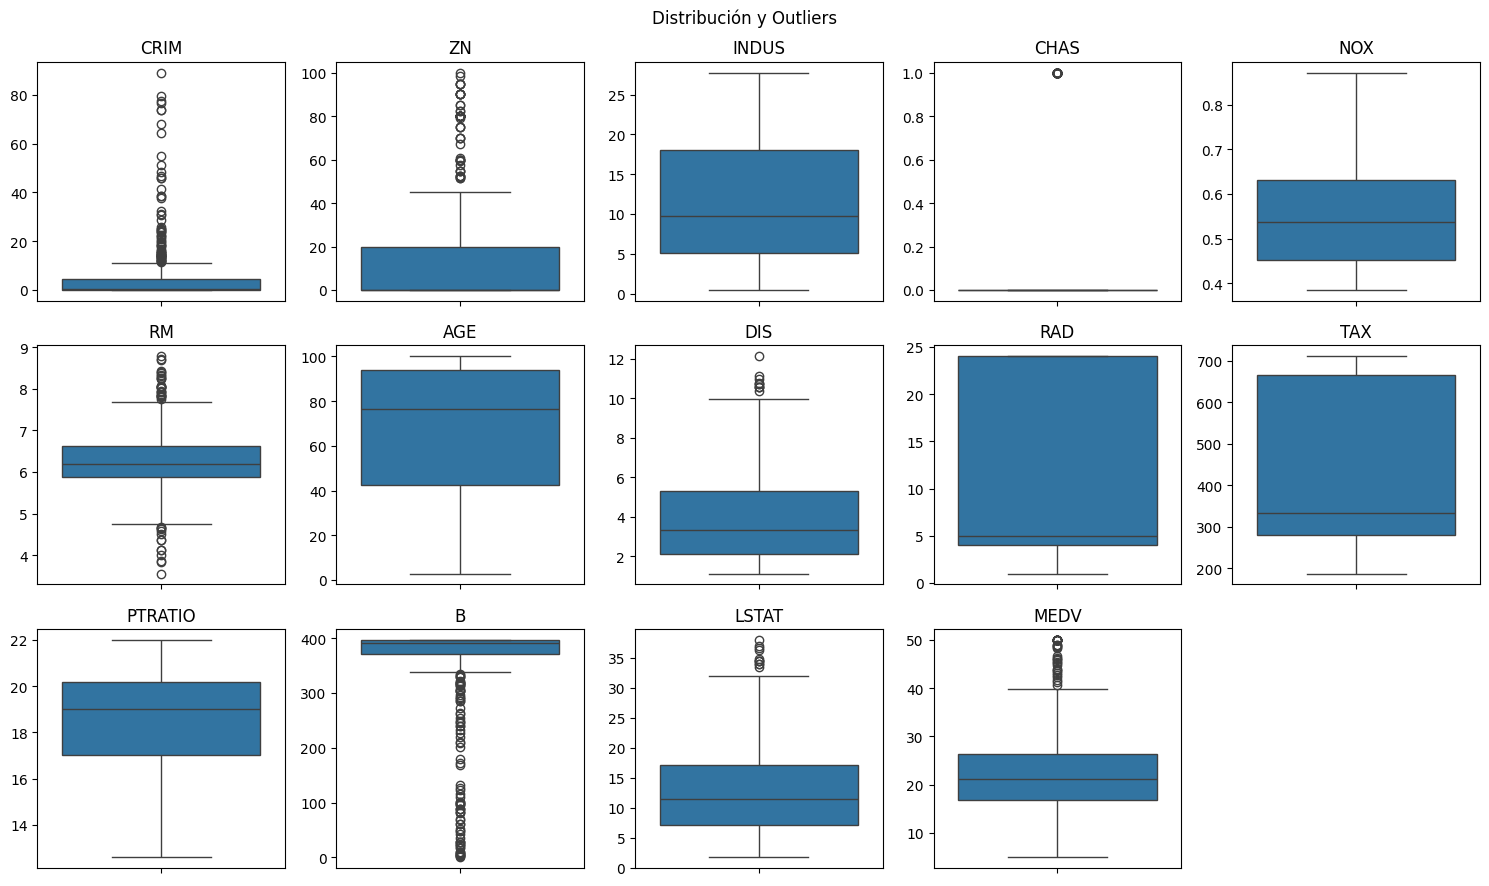

In [12]:
colum = data_orig.columns

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for ax, col in zip(axes.flat, colum):
    sns.boxplot(y=data_orig[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')

for ax in axes.flat[len(colum):]:
    ax.set_visible(False)

fig.suptitle('Distribución y Outliers')
plt.tight_layout()
plt.show()

**Variables con outliers notorios:**
- CRIM (tasa de criminalidad): valores máximos del bigote superior alrededor de 15. Los outliers pueden deberse a valores pertenecientes a zonas específicas de la ciudad. Se imputan nulos por mediana.
- ZN (proporción de terrenos residenciales zonificados de más de 25 mil pies cuadrados): mayoría de los valores en cero (o hasta 20%) y una cola larga de zonas residenciales exclusivas. Se evaluará si se imputan nulos por la mediana.
- CHAS (1 si el tramo limita con el río Charles; 0 de lo contrario): variable booleana. Lo único destacable es que la mayoría de los datos indican no limitar con el río. No se escala pero se imputarán nulos por moda.
- RM (promedio de habitaciones por vivienda): distribución con colas hacia ambos lados, lo que apunta a una distribución simétrica. Se presentan viviendas cuya mediana de cantidad de habitaciones ronda 6 pero se destacan algunas con menos de 5 y más de 8. Se escalará con StandardScaler y se imputarán nulos por media.
- B (proporción de habitantes negros): distribución sesgada a la izquierda, posiblemente documenta zonas con población negra. Posible imputación de nulos: por mediana.

#### Separacion de datos en train y test

Se deja el 20% de las filas para test y el 80% restante para train. Por lo tanto, de 535 filas quedan 107 en test y 428 en train.

In [13]:
from sklearn.model_selection import train_test_split
X = data_orig.drop('MEDV', axis=1)
y = data_orig['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(428, 13) (107, 13) (428,) (107,)


#### Escalado e imputacion con modelo LinearRegression

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

Los nulos de la mayor parte de las variables presentes se imputarán con la mediana debido a la asimetría antes vista, salvo CHAS y RM, que será por moda y media, respectivamente. Con respecto al escalado, se elige StandarScaler por ser el más adecuado para los modelos posteriores.

In [15]:
imp_mediana = SimpleImputer(strategy="median")
imp_moda = SimpleImputer(strategy="most_frequent")
imp_media = SimpleImputer(strategy="mean")

In [16]:
cols_por_mediana = ['CRIM', 'ZN', 'INDUS', 'NOX', 'AGE', 'DIS', 'RAD', 'TAX','PTRATIO', 'B', 'LSTAT']
cols_por_media = ['RM']
cols_por_moda = ['CHAS']

In [17]:
pipe_mediana = Pipeline([
    ('imputer', imp_mediana),
    ('scaler', StandardScaler())
])

pipe_media = Pipeline([
    ('imputer', imp_media),
    ('scaler', StandardScaler())
])

pipe_moda = Pipeline([
    ('imputer', imp_moda)
])

In [ ]:
preprocesador = ColumnTransformer([
    ('mediana', pipe_mediana, cols_por_mediana),
    ('media', pipe_media, cols_por_media),
    ('moda', pipe_moda, cols_por_moda)
])

# Pipeline para armar el modelo de regresión lineal básico
pipeline = Pipeline([
    ('preprocesador', preprocesador),
    ('model', LinearRegression())
])

# Ajustado de train
pipeline.fit(X_train, y_train)

# Evaluación en Test
y_pred = pipeline.predict(X_test)

In [19]:
# Comprobar que no hay valores nulos en el resultado
print("¿Hay nulos en las predicciones?:", np.isnan(y_pred).any())

# Comprobar la cantidad de predicciones
print("Cantidad de predicciones:", len(y_pred))

¿Hay nulos en las predicciones?: False
Cantidad de predicciones: 107


#### Validacion cruzada

In [20]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error, root_mean_squared_error

In [21]:
# Validación cruzada (5 pliegues) sobre train
kf = KFold(n_splits=5, shuffle=True, random_state=123)
scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error")

# Resultados por pliegue
print("RMSE por fold:", -(scores.round(2)))

# Promedio y desvío estándar con el formato del ejemplo
print(f"RMSE = {-scores.mean():.3f} +/- {scores.std():.3f}")

RMSE por fold: [5.74 7.19 7.41 6.71 5.59]
RMSE = 6.529 +/- 0.741


In [22]:
r2 = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2')
print(f"R² = {r2.mean():.3f} +/- {r2.std():.3f}")

R² = 0.541 +/- 0.049


El modelo LinearRegression obtuvo un R² promedio de 0.541 (± 0.049) en validación cruzada con 5 pliegues, junto con un RMSE de 6.529 (± 0.741) miles de dólares. Esto indica que el modelo explica aproximadamente el 54,1% de la varianza del valor mediano de las viviendas, con un error promedio de predicción cercano a los $6.500.

El desvío de 0.049 en R² es moderado, y la dispersión del RMSE entre pliegues también lo es: los valores van de 5.74 a 7.41, aproximadamente un 29% de diferencia entre el mejor y el peor pliegue. El resultado es aceptable como línea de base.


### Algoritmos de gradiente descendente:

Los algoritmos de la siguiente celda fueron copiados del archivo brindado por la catedra:

https://drive.google.com/file/d/1EuafOyyp3MPls42Na4OOSeb0gTw-BOuU/view?usp=drive_link

In [23]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    n = X_train.shape[0]
    m = X_train.shape[1]
    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []
    test_errors = []

    for _ in range(epochs):
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum
        gradient = np.transpose(grad_mul).reshape(-1, 1)

        W = W - (lr * gradient)

    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de validación')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    plt.show()

    return W


def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)
            W = W - (lr * gradient)

    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de validación')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y validación vs iteraciones (SGD)')
    plt.show()

    return W


def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=16):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(0, n, batch_size):
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size
            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de validación')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y validación vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

#### Implementacion de los algoritmos GD

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error, root_mean_squared_error

In [25]:
# Validación separada desde el train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=123
)

y_tr_gd   = y_tr.values.reshape(-1, 1)
y_val_gd  = y_val.values.reshape(-1, 1)
y_test_gd = y_test.values.reshape(-1, 1)

print("Train:", X_tr.shape)
print("Validación:", X_val.shape)
print("Test:", X_test.shape)


Train: (342, 13)
Validación: (86, 13)
Test: (107, 13)


In [26]:
pipeline.fit(X_tr, y_tr)

print('R² en validación:', round(r2_score(y_val, pipeline.predict(X_val)),3))

R² en validación: 0.564


In [27]:
print(f"Dimensiones de X_tr:   {X_tr.shape}, y_tr:   {y_tr.shape}")
print(f"Dimensiones de X_val:  {X_val.shape}, y_val:  {y_val.shape}")
print(f"Dimensiones de X_test: {X_test.shape}, y_test: {y_test.shape}")

Dimensiones de X_tr:   (342, 13), y_tr:   (342,)
Dimensiones de X_val:  (86, 13), y_val:  (86,)
Dimensiones de X_test: (107, 13), y_test: (107,)


#### Comportamiento con Gradiente Descendiente

In [28]:
prep = pipeline.named_steps['preprocesador'] # se asegura la imputacion y escalado elegidos anteriormente

X_tr_esc   = prep.fit_transform(X_tr)
X_val_esc  = prep.transform(X_val)
X_test_esc = prep.transform(X_test)


Entrenamiento con Batch GD


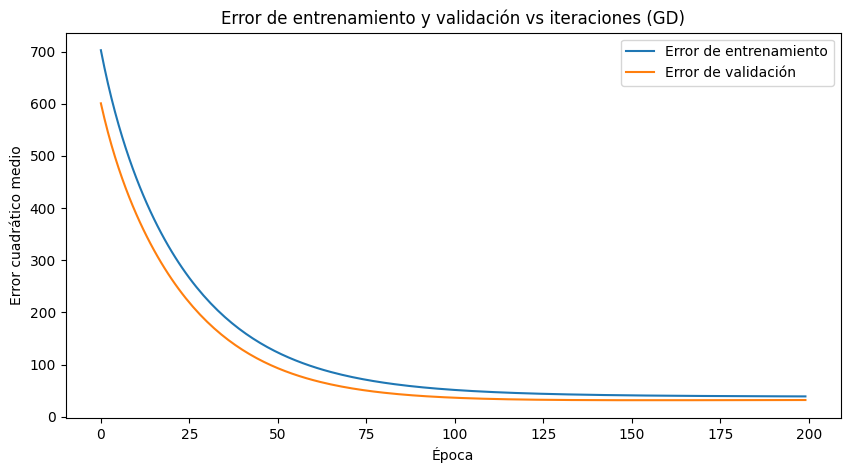

Entrenamiento con SGD


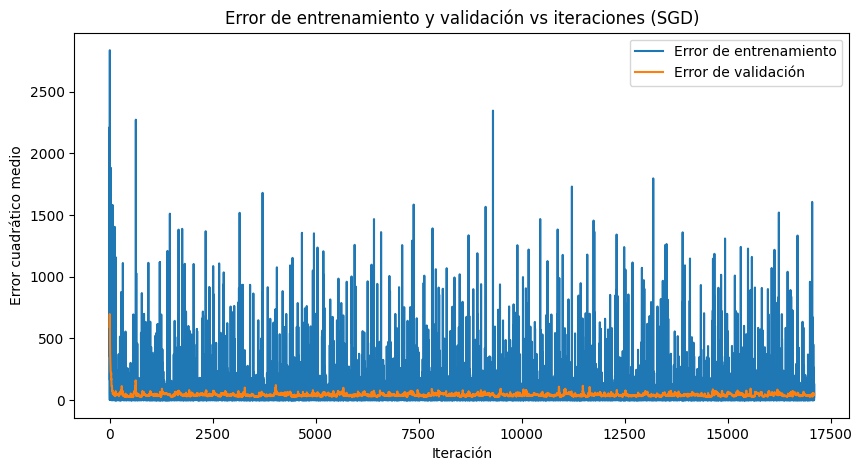

Entrenamiento con Mini-Batch GD


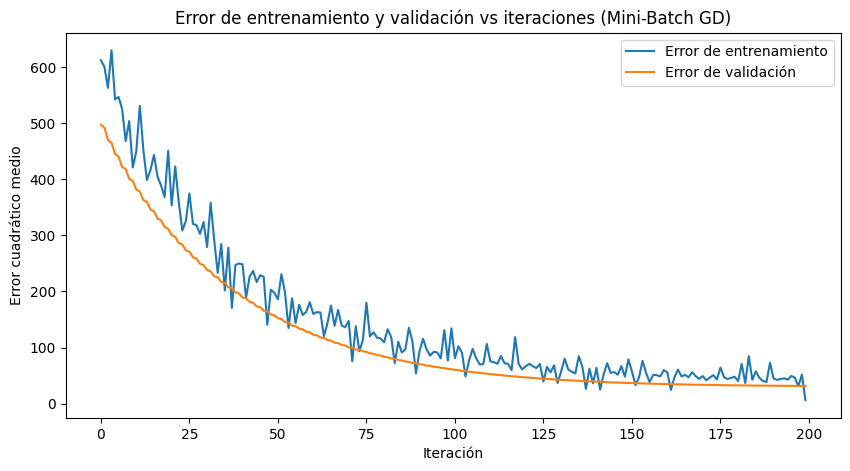

In [29]:
np.random.seed(123)

# 1. Batch Gradient Descent
print("Entrenamiento con Batch GD")
W_gd   = gradient_descent(X_tr_esc, y_tr_gd, X_val_esc, y_val_gd, lr=0.01, epochs=200)

# 2. Stochastic Gradient Descent (SGD)
print("Entrenamiento con SGD")
W_sgd  = stochastic_gradient_descent(X_tr_esc, y_tr_gd, X_val_esc, y_val_gd, lr=0.01, epochs=50)

# 3. Mini-Batch Gradient Descent
print("Entrenamiento con Mini-Batch GD")
W_mbgd = mini_batch_gradient_descent(X_tr_esc, y_tr_gd, X_val_esc, y_val_gd, lr=0.01, epochs=100, batch_size=280)

**Observaciones:**

GD: el error cae de forma suave y sostenida. A las 50 épocas todavía está en descenso pronunciado, se aplana cerca de las 150 y a las 200 continúa bajando levemente sin haber alcanzado del todo la asíntota.

SGD: el error desciende de forma mucho más abrupta, estabilizándose alrededor de la quinta época tanto en entrenamiento como en validación. Sin embargo, presenta oscilaciones residuales (curva más ruidosa)que persisten hasta el final.

Mini-batch: alcanza un comportamiento intermedio. Converge en unas 15 épocas y lo hace con una curva notablemente suave. El promediado del gradiente sobre 32 observaciones por paso cancela buena parte del ruido sin sacrificar velocidad de convergencia.

Los tres métodos convergen a valores de MSE equivalentes (aproximadamente 32-35 en entrenamiento y 22-25 en validación). Lo que los diferencia es la cantidad de actualizaciones necesarias y estabilidad del recorrido.

In [30]:
# Poner columna de unos a X_test
X_test_b = np.hstack((np.ones((X_test_esc.shape[0], 1)), X_test_esc))

# Predicciones de cada modelo en Test
y_pred_gd   = X_test_b @ W_gd
y_pred_sgd  = X_test_b @ W_sgd
y_pred_mbgd = X_test_b @ W_mbgd

# Evaluación de cada variante en Test
mse_gd   = mean_squared_error(y_test_gd, y_pred_gd)
mse_sgd  = mean_squared_error(y_test_gd, y_pred_sgd)
mse_mbgd = mean_squared_error(y_test_gd, y_pred_mbgd)

r2_gd   = r2_score(y_test_gd, y_pred_gd)
r2_sgd  = r2_score(y_test_gd, y_pred_sgd)
r2_mbgd = r2_score(y_test_gd, y_pred_mbgd)

rmse_gd   = root_mean_squared_error(y_test_gd, y_pred_gd)
rmse_sgd  = root_mean_squared_error(y_test_gd, y_pred_sgd)
rmse_mbgd = root_mean_squared_error(y_test_gd, y_pred_mbgd)

mae_gd    = mean_absolute_error(y_test_gd, y_pred_gd)
mape_gd   = mean_absolute_percentage_error(y_test_gd, y_pred_gd) * 100
mae_sgd   = mean_absolute_error(y_test_gd, y_pred_sgd)
mape_sgd  = mean_absolute_percentage_error(y_test_gd, y_pred_sgd) * 100
mae_mbgd  = mean_absolute_error(y_test_gd, y_pred_mbgd)
mape_mbgd = mean_absolute_percentage_error(y_test_gd, y_pred_mbgd) * 100

results = pd.DataFrame({
    'Algoritmo': ['Batch GD', 'Stochastic GD', 'Mini-Batch GD'],
    'MSE': [mse_gd, mse_sgd, mse_mbgd],
    'RMSE': [rmse_gd, rmse_sgd, rmse_mbgd],
    "R2": [r2_gd, r2_sgd, r2_mbgd],
    "MAE": [mae_gd, mae_sgd, mae_mbgd],
    "MAPE": [mape_gd, mape_sgd, mape_mbgd]
})
results

,Algoritmo,MSE,RMSE,R2,MAE,MAPE
0,Batch GD,26.964923,5.192776,0.622411,3.696584,20.540971
1,Stochastic GD,38.164603,6.177751,0.465582,4.911255,27.301943
2,Mini-Batch GD,29.852824,5.463774,0.581971,3.572060,18.658126


Observaciones sobre los pesos:

Los pesos obtenidos mediante los métodos de gradiente son de magnitud menor a los de LinearRegression. Esto no indica una mejor optimización, significa que el descenso por gradiente no llegó a converger a la solución exacta de mínimos cuadrados dentro del número de épocas fijado. Al partir de pesos pequeños y avanzar un número limitado de pasos, el algoritmo se detiene antes del óptimo, puede mejorar o empeorar el error de test según el caso.


#### Regresion de Ridge

In [31]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_esc, y_tr)

y_pred_train_ridge = ridge.predict(X_tr_esc)
y_pred_test_ridge  = ridge.predict(X_test_esc)

print("Train RMSE:", root_mean_squared_error(y_tr, y_pred_train_ridge))
print("Test RMSE:", root_mean_squared_error(y_test, y_pred_test_ridge))
print("Train R2 Score:", r2_score(y_tr, y_pred_train_ridge))
print("Test R2 Score:", r2_score(y_test, y_pred_test_ridge))

Train RMSE: 6.061458894311679
Test RMSE: 5.324499768623858
Train R2 Score: 0.626060662487019
Test R2 Score: 0.6030112250245241


#### Regresion Lasso

In [32]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_tr_esc, y_tr)

y_pred_train_lasso = lasso.predict(X_tr_esc)
y_pred_test_lasso  = lasso.predict(X_test_esc)

print("Train RMSE:", root_mean_squared_error(y_tr, y_pred_train_lasso))
print("Test RMSE:", root_mean_squared_error(y_test, y_pred_test_lasso))
print("Train R2 Score:", r2_score(y_tr, y_pred_train_lasso))
print("Test R2 Score:", r2_score(y_test, y_pred_test_lasso))

Train RMSE: 6.092431994601001
Test RMSE: 5.216674908228743
Train R2 Score: 0.622229356506678
Test R2 Score: 0.6189270266200928


#### Regresión con ElasticNet

In [33]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_tr_esc, y_tr)

y_pred_train_elastic = elastic.predict(X_tr_esc)
y_pred_test_elastic  = elastic.predict(X_test_esc)

print("Train RMSE:", root_mean_squared_error(y_tr, y_pred_train_elastic))
print("Test RMSE:", root_mean_squared_error(y_test, y_pred_test_elastic))
print("Train R2 Score:", r2_score(y_tr, y_pred_train_elastic))
print("Test R2 Score:", r2_score(y_test, y_pred_test_elastic))


Train RMSE: 6.146094330411047
Test RMSE: 5.199258145768682
Train R2 Score: 0.6155452167072526
Test R2 Score: 0.6214673336537726


In [34]:
lineal = LinearRegression()
lineal.fit(X_tr_esc, y_tr)
y_pred_test_lineal = lineal.predict(X_test_esc)

comparacion = pd.DataFrame({
    "Modelo": ["LinearRegression", "Batch GD", "SGD", "Mini-Batch GD", "Ridge", "Lasso", "Elastic Net"],
    "R² Test": [
        r2_score(y_test, y_pred_test_lineal),
        r2_gd,
        r2_sgd,
        r2_mbgd,
        r2_score(y_test, y_pred_test_ridge),
        r2_score(y_test, y_pred_test_lasso),
        r2_score(y_test, y_pred_test_elastic),
    ],
    "RMSE Test": [
        root_mean_squared_error(y_test, y_pred_test_lineal),
        rmse_gd,
        rmse_sgd,
        rmse_mbgd,
        root_mean_squared_error(y_test, y_pred_test_ridge),
        root_mean_squared_error(y_test, y_pred_test_lasso),
        root_mean_squared_error(y_test, y_pred_test_elastic)
    ]
})

comparacion.sort_values("R² Test", ascending=False)

,Modelo,R² Test,RMSE Test
1,Batch GD,0.622411,5.192776
6,Elastic Net,0.621467,5.199258
5,Lasso,0.618927,5.216675
4,Ridge,0.603011,5.324500
0,LinearRegression,0.601153,5.336944
3,Mini-Batch GD,0.581971,5.463774
2,SGD,0.465582,6.177751


<Figure size 800x600 with 0 Axes>

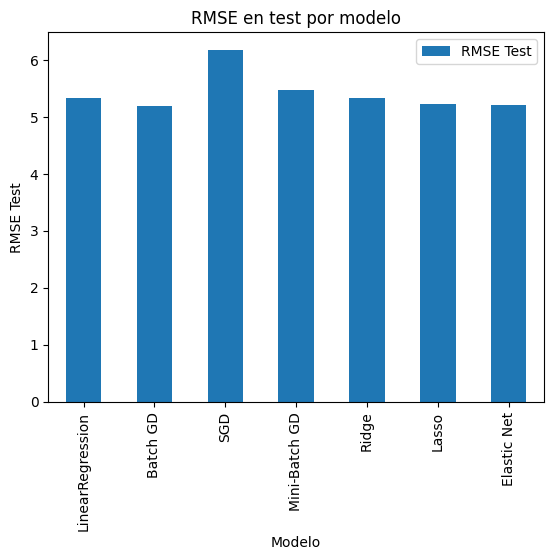

In [35]:
plt.figure(figsize=(8, 6))
comparacion.plot(
    x="Modelo",
    y="RMSE Test",
    kind="bar"
)
plt.ylabel("RMSE Test")
plt.title("RMSE en test por modelo")
plt.show()


#### Optimización de hiperparámetros
**de Gradiente Descendiente**

**de Ridge y Lasso**

In [36]:
from sklearn.model_selection import GridSearchCV

Ridge {'model__alpha': np.float64(31.622776601683793)} 6.722477814559791
Lasso {'model__alpha': np.float64(0.1)} 6.746545742510395


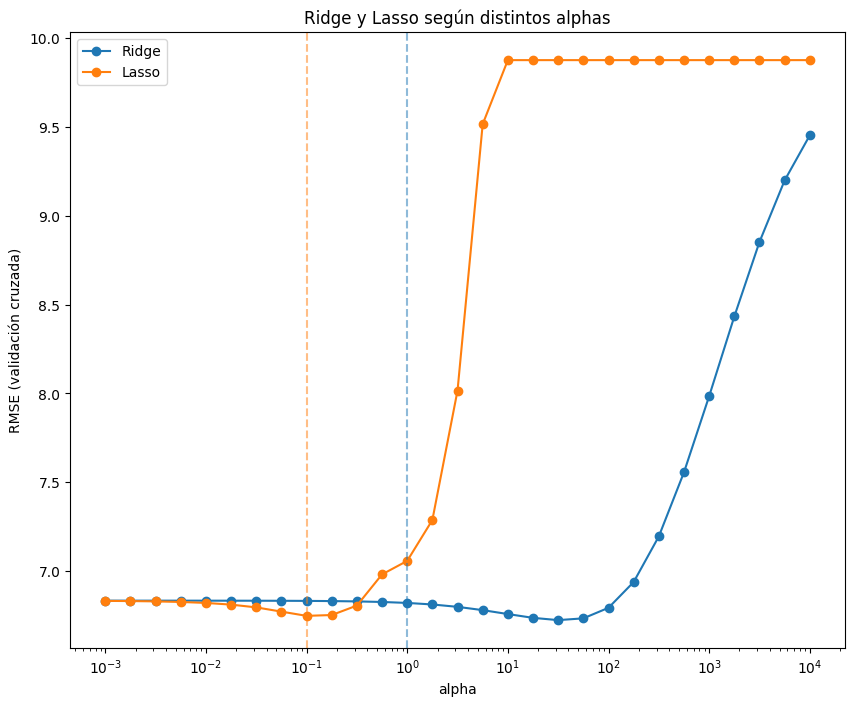

In [37]:
alphas = np.logspace(-3, 4, 29)

plt.figure(figsize=(10, 8))
for nombre, modelo in [("Ridge", Ridge()), ("Lasso", Lasso(max_iter=10000))]:
    pipe_reg = Pipeline([('preprocesador', preprocesador), ('model', modelo)])
    grid = GridSearchCV(pipe_reg, {"model__alpha": alphas}, cv=5,
                        scoring="neg_root_mean_squared_error")
    grid.fit(X_tr, y_tr)
    plt.plot(alphas, -grid.cv_results_["mean_test_score"], marker="o", label=nombre)
    print(nombre, grid.best_params_, -grid.best_score_)
plt.axvline(1.0, color="C0", linestyle="--", alpha=0.5)  # Ridge actual
plt.axvline(0.1, color="C1", linestyle="--", alpha=0.5)  # Lasso actual
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("RMSE (validación cruzada)")
plt.title("Ridge y Lasso según distintos alphas")
plt.legend()
plt.show()

**Lasso:** el mejor alpha es aprox. 0.1, con un RMSE mínimo de aprox. 6.75, y coincide con el valor que ya usábamos. A partir de alpha ≈ 0.3 el error sube de forma abrupta, y desde alpha = 10 se estabiliza en aprox. 9.9.

**Ridge:** el mejor alpha es aprox. 30, con un RMSE de aprox. 6.72, apenas menor que el mínimo de Lasso. La curva es casi plana hasta ese punto, por lo que el valor que usábamos (1.0) da un resultado muy similar. Desde alpha ≈ 100 el error empieza a subir.